In [1]:
import jax
# JAX truncates float64 to float32 unless this is set.  Enable it before any
# array is created (see Remark 1 of the README).
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np

import pyproj
import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 20

import optax
from OkadaJAX import OkadaWrapper
okada = OkadaWrapper()

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
# os.makedirs("figs_loss", exist_ok=True)

# Generate observation data (synthetic data + some noise)

In [3]:
# domain
lon_min, lon_max = 142, 148
lat_min, lat_max = 37, 43
dlon, dlat = 0.25, 0.25 # very sparse
nlon, nlat = int((lon_max-lon_min)/dlon)+1, int((lat_max-lat_min)/dlon)+1
lon_mid, lat_mid = (lon_min+lon_max)/2, (lat_min+lat_max)/2


# coordinate transformation
ll2xy = pyproj.Transformer.from_crs(
    crs_from="EPSG:4326", # WGS84
    crs_to=f"+proj=tmerc +lon_0={lon_mid} +lat_0={lat_mid} +ellps=WGS84 +datum=WGS84 +units=km", 
    always_xy=True
)

lon = jnp.linspace(lon_min, lon_max, nlon)
lat = jnp.linspace(lat_min, lat_max, nlat)
Lon, Lat = jnp.meshgrid(lon, lat)
X_obs, Y_obs = ll2xy.transform(Lon, Lat)

X_min, X_max = X_obs.min(), X_obs.max()
Y_min, Y_max = Y_obs.min(), Y_obs.max()
dX, dY = (X_max - X_min) / 2, (Y_max - Y_min) / 2
print(dX, dY)


coords = {
    "x": X_obs,
    "y": Y_obs
}

267.0689477487547 335.28939693235236


In [4]:
# source parameters
lat_fault = 40.2224
lon_fault = 144.8678
x_fault, y_fault = ll2xy.transform(lon_fault, lat_fault)

print(x_fault, y_fault) # km

params_true = {
    "x_fault": jnp.array(x_fault),
    "y_fault": jnp.array(y_fault),
    "depth": jnp.array(0.1), # km
    "length": jnp.array(218.0), # km
    "width": jnp.array(46.0), # km
    "strike": jnp.array(189.0), # degree
    "dip": jnp.array(60.0), # degree
    "rake": jnp.array(270.0), # degree
    "slip": jnp.array(5.62) # m
}


print("True parameters:")

for name in params_true.keys():
    value = params_true[name]
    print(name, value)

-11.25235992480785 24.70296061567198
True parameters:
x_fault -11.25235992480785
y_fault 24.70296061567198
depth 0.1
length 218.0
width 46.0
strike 189.0
dip 60.0
rake 270.0
slip 5.62


In [5]:
ux_obs, uy_obs, uz_obs = okada.compute(coords, params_true, compute_strain=False, is_degree=True, fault_origin="topleft") 

key = jax.random.PRNGKey(123)
err = 0.05 * jax.random.normal(key, shape=(nlon, nlat, 3))

ux_obs += err[:, :, 0]
uy_obs += err[:, :, 1]
uz_obs += err[:, :, 2]

In [6]:
np.savetxt("ux_obs.txt", ux_obs)
np.savetxt("uy_obs.txt", uy_obs)
np.savetxt("uz_obs.txt", uz_obs)

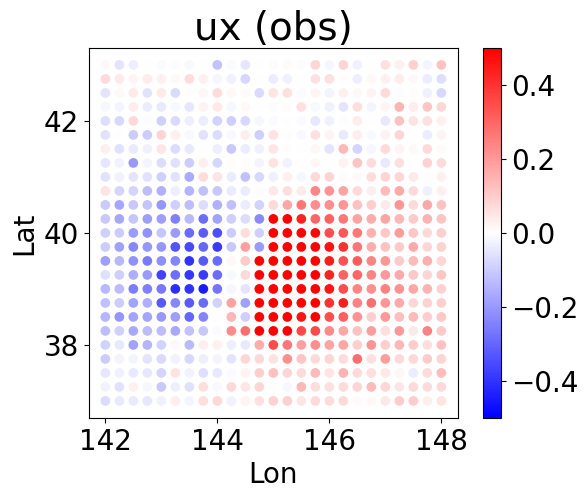

In [7]:
fig, ax = plt.subplots()
im = ax.scatter(Lon, Lat, c=ux_obs, cmap="bwr", vmin=-0.5, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.set_title("ux (obs)", fontsize=28)
fig.colorbar(im)
fig.show()
# plt.tight_layout()
# fig.savefig("figs_loss/ux_obs.png")

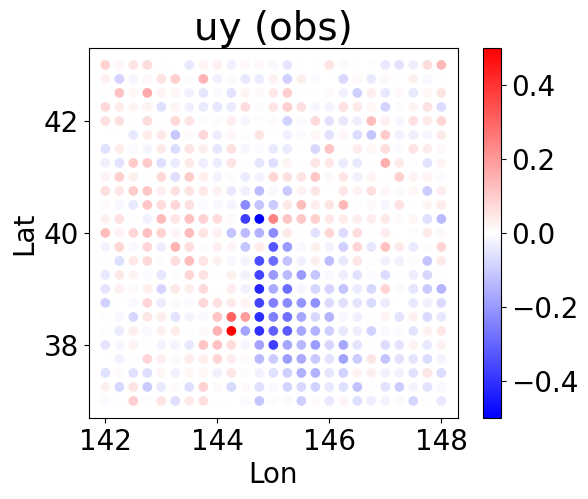

In [8]:
fig, ax = plt.subplots()
im = ax.scatter(Lon, Lat, c=uy_obs, cmap="bwr", vmin=-0.5, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.set_title("uy (obs)", fontsize=28)
fig.colorbar(im)
fig.show()
# plt.tight_layout()
# fig.savefig("figs_loss/uy_obs.png")

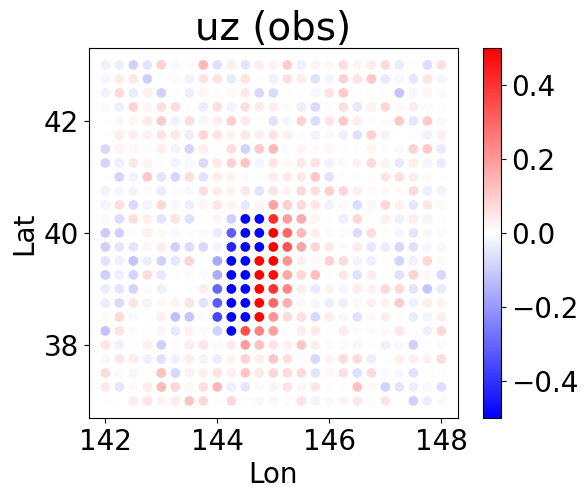

In [9]:
fig, ax = plt.subplots()
im = ax.scatter(Lon, Lat, c=uz_obs, cmap="bwr", vmin=-0.5, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.set_title("uz (obs)", fontsize=28)
fig.colorbar(im)
fig.show()
# plt.tight_layout()
# fig.savefig("figs_loss/uz_obs.png")

# Gradient-based parameter estimation

For a successful optimization, it is desirable for the gradients with respect to each parameter to have the same order of magnitude.
Here, we perform a simple scaling: for each parameter `p`, we set a representative value `p0` and width `dp` in advance, and optimize the normalized parameter `q = (p-p0)/dp`.


[NOTE]

For some parameters (especially `x_fault` and `y_fault`), choise of initial values can greatly affect the results;
if they are chosen too far from the optimal values, the optimization will fail (the solution will diverge). 
In practical cases, it may be safer to keep those variables fixed at some values (= set `requires_grad=False`) and optimize only the other parameters.

The purpose here is only to demonstrate conceptually that optimization is possible using gradients obtained by automatic differentiation.
Actual applications would require more techniques.

In [10]:
def scale(p, p0, dp):
    q = {}
    for key in p:
        q[key] = (p[key] - p0[key]) / dp[key]
    return q

def unscale(q, p0, dp):
    p = {}
    for key in q:
        p[key] = p0[key] + dp[key] * q[key]
    return p

In [11]:
# parameters; target of optimization 
# choose appropriate initial values
params = {
    "x_fault": jnp.array(0.0),  
    "y_fault": jnp.array(10.0),
    "depth": jnp.array(1.0),
    "length": jnp.array(150.0),
    "width": jnp.array(60.0),
    "strike": jnp.array(200.0),
    "dip": jnp.array(45.0),
    "rake": jnp.array(300.0),
    "slip": jnp.array(10.0)
}

# save initial parameters; this is also used as the representative value 
p0 = {key: val for key, val in params.items()}

print("Initial parameters:")

for name in p0.keys():
    value = p0[name]
    print(name, value)


# choose appropriate width
dp = {
    "x_fault": jnp.array(dX), # scaled by domain size
    "y_fault": jnp.array(dY),
    "depth": jnp.array(10.0),
    "length": jnp.array(100.0),
    "width": jnp.array(100.0),
    "strike": jnp.array(180.0),
    "dip": jnp.array(90.0),
    "rake": jnp.array(180.0),
    "slip": jnp.array(5.0)
}

Initial parameters:
x_fault 0.0
y_fault 10.0
depth 1.0
length 150.0
width 60.0
strike 200.0
dip 45.0
rake 300.0
slip 10.0


In [12]:
ux, uy, uz = okada.compute(coords, params, compute_strain=False, is_degree=True, fault_origin="topleft")

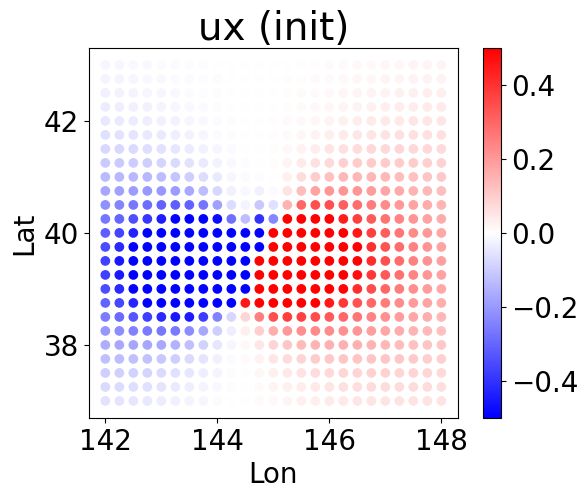

In [13]:
fig, ax = plt.subplots()
im = ax.scatter(Lon, Lat, c=ux, cmap="bwr", vmin=-0.5, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.set_title("ux (init)", fontsize=28)
fig.colorbar(im)
fig.show()
# plt.tight_layout()
# fig.savefig("figs_loss/ux_init.png")

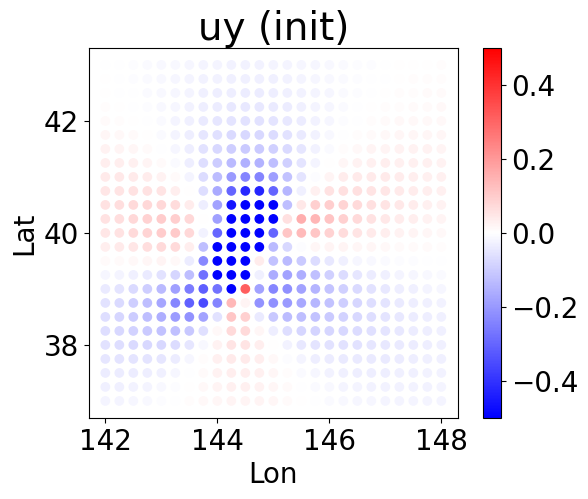

In [14]:
fig, ax = plt.subplots()
im = ax.scatter(Lon, Lat, c=uy, cmap="bwr", vmin=-0.5, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.set_title("uy (init)", fontsize=28)
fig.colorbar(im)
fig.show()
# plt.tight_layout()
# fig.savefig("figs_loss/uy_init.png")

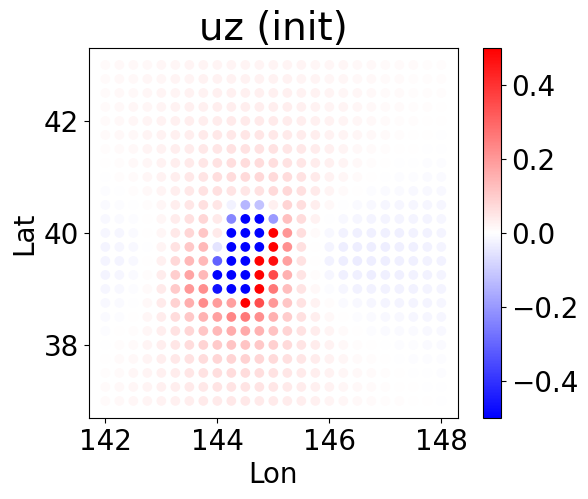

In [15]:
fig, ax = plt.subplots()
im = ax.scatter(Lon, Lat, c=uz, cmap="bwr", vmin=-0.5, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.set_title("uz (init)", fontsize=28)
fig.colorbar(im)
fig.show()
# plt.tight_layout()
# fig.savefig("figs_loss/uz_init.png")

In [16]:
# The loss sits on a plateau around iteration 1000 and leaves it at a point
# that depends on the noise realisation, so 2000 iterations converge for some
# realisations and not for others.  4000 is enough either way, and with
# jax.jit each iteration takes about 2 ms.
niter = 4000
ls = np.zeros(niter)

# optimizer handles normalized parameters
scaled_params = scale(params, p0, dp)
optimizer = optax.adam(learning_rate=1e-3)
opt_state = optimizer.init(scaled_params)


def loss(scaled_params):
    # unscale
    params = unscale(scaled_params, p0, dp)
    ux, uy, uz = okada.compute(coords, params, compute_strain=False, is_degree=True, fault_origin="topleft")
    res1 = ux - ux_obs
    res2 = uy - uy_obs
    res3 = uz - uz_obs
    l = 0.5 * jnp.sum(res1 * res1 + res2 * res2 + res3 * res3)
    return l

# jax.jit compiles the whole step once; without it every call dispatches the
# kernel's operations one by one, about 100 times slower (see Remark 5).
loss_and_grad = jax.jit(jax.value_and_grad(loss))



for iter in range(niter):
    l, grads = loss_and_grad(scaled_params)
    updates, opt_state = optimizer.update(grads, opt_state, scaled_params)
    scaled_params = optax.apply_updates(scaled_params, updates)

    ls[iter] = l

    if iter % 100 == 0 or iter == niter - 1:
        print(f"Iteration {iter}: Loss = {l}")

Iteration 0: Loss = 95.39895382019182
Iteration 100: Loss = 44.171209307834374
Iteration 200: Loss = 32.59874451229797
Iteration 300: Loss = 28.880934142117237
Iteration 400: Loss = 27.42246255857374
Iteration 500: Loss = 26.70088428120266
Iteration 600: Loss = 26.145925890558864
Iteration 700: Loss = 24.73347993205161
Iteration 800: Loss = 24.205696388962245
Iteration 900: Loss = 23.832085791106707
Iteration 1000: Loss = 23.544814964885685
Iteration 1100: Loss = 23.321453825410657
Iteration 1200: Loss = 23.13586834203497
Iteration 1300: Loss = 22.97171523999192
Iteration 1400: Loss = 22.8224189578763
Iteration 1500: Loss = 22.686572293097036
Iteration 1600: Loss = 22.564683300637846
Iteration 1700: Loss = 22.45760518707579
Iteration 1800: Loss = 22.36586204749573
Iteration 1900: Loss = 22.28938509501228
Iteration 2000: Loss = 22.22746046803348
Iteration 2100: Loss = 22.17880402921606
Iteration 2200: Loss = 22.141707313109187
Iteration 2300: Loss = 22.114187625085485
Iteration 2400: Lo

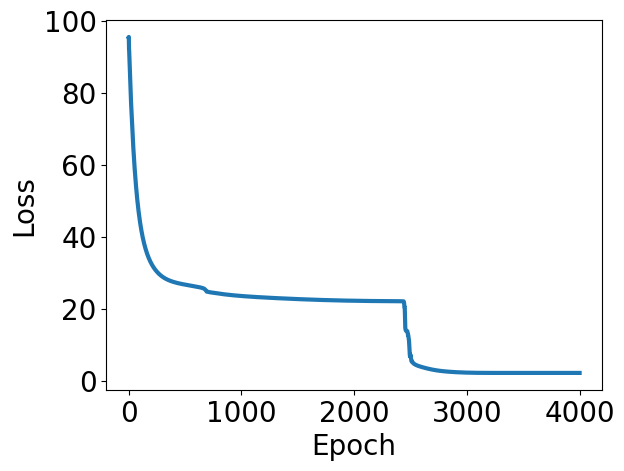

In [17]:
fig, ax = plt.subplots()
ax.plot(ls, lw=3)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
fig.show()
# plt.tight_layout()
# fig.savefig("figs_loss/loss.png")

In [18]:
# Calculate std via Laplace approximation
def paramsdict2matrix(dict):
    keys = list(dict.keys())
    return jnp.stack([
        jnp.stack([
            dict[row_key][col_key] for col_key in keys]) 
            for row_key in keys
    ])

hes = jax.hessian(loss)(scaled_params)
H = paramsdict2matrix(hes)
print(H)


# Sigma = jnp.linalg.inv(H)
Sigma = np.linalg.inv(H)
print(Sigma)

# Variance = jnp.diag(Sigma)
Variance = np.diag(Sigma)
print(Variance)


# Std = jnp.sqrt(Variance)
# Std = jnp.sqrt(jnp.maximum(Variance, 0.0))
Std = np.sqrt(np.maximum(Variance, 0.0))
print(Std)

Std2 = {}

for i, key in enumerate(params):
    Std2[key] = dp[key] * Std[i]

[[ 2.52327377e+02  2.43244003e+02 -1.74305812e+01 -3.11783336e+00
  -3.43525348e+01  2.42075603e+01 -6.31678927e-01 -6.36927119e+01
   5.76008206e+01]
 [ 2.43244003e+02  8.66464261e+02 -1.03032035e+00  1.14257659e+01
   1.06226107e+00 -1.85837499e+02  9.25478035e+01  2.16830899e+02
  -3.28453921e+01]
 [-1.74305812e+01 -1.03032035e+00  1.79745804e+02 -3.17434634e+01
   2.30587913e+01  1.16343894e+03  3.40618035e+01 -5.08231523e+02
  -5.04627103e+02]
 [-3.11783336e+00  1.14257659e+01 -3.17434634e+01  1.80158955e+03
   4.75416542e+00 -9.38277396e+02  4.21903467e-01  1.01776733e+02
   3.09908290e+02]
 [-3.43525348e+01  1.06226107e+00  2.30587913e+01  4.75416542e+00
   1.13240033e+02  3.83862536e+02  1.20364048e+02 -2.65317421e+02
   9.69580471e+01]
 [ 2.42075603e+01 -1.85837499e+02  1.16343894e+03 -9.38277396e+02
   3.83862536e+02  3.01058978e+04  8.90675547e+02 -1.52604607e+04
  -7.82611081e+02]
 [-6.31678927e-01  9.25478035e+01  3.40618035e+01  4.21903467e-01
   1.20364048e+02  8.9067554

In [19]:
params = unscale(scaled_params, p0, dp)


print("  param  |   true  |   init  |   est   |   std   | est-std | est+std |")

for name in params.keys():
    init = p0[name]
    true = params_true[name]
    est = params[name]
    std = Std2[name]
    print(f"{name:>8} | {true:7.3f} | {init:7.3f} | {est:7.3f} | {std:7.3f} | {est-std:7.3f} | {est+std:7.3f} |")


ux, uy, uz = okada.compute(coords, params, compute_strain=False, is_degree=True, fault_origin="topleft")

  param  |   true  |   init  |   est   |   std   | est-std | est+std |
   depth |   0.100 |   1.000 |   0.145 |   1.080 |  -0.935 |   1.226 |
     dip |  60.000 |  45.000 |  59.732 |   6.978 |  52.754 |  66.709 |
  length | 218.000 | 150.000 | 217.328 |   2.437 | 214.891 | 219.766 |
    rake | 270.000 | 300.000 | 269.897 |   4.228 | 265.669 | 274.125 |
    slip |   5.620 |  10.000 |   5.658 |   0.089 |   5.568 |   5.747 |
  strike | 189.000 | 200.000 | 189.172 |   2.479 | 186.693 | 191.651 |
   width |  46.000 |  60.000 |  45.600 |  12.608 |  32.992 |  58.208 |
 x_fault | -11.252 |   0.000 | -11.019 |  20.805 | -31.825 |   9.786 |
 y_fault |  24.703 |  10.000 |  24.668 |  14.130 |  10.538 |  38.799 |


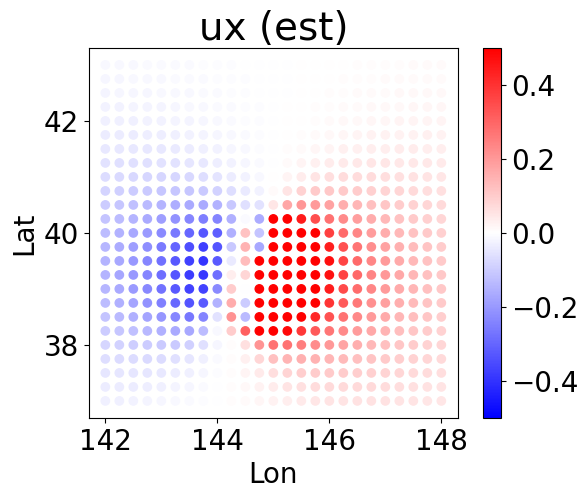

In [20]:
fig, ax = plt.subplots()
im = ax.scatter(Lon, Lat, c=ux, cmap="bwr", vmin=-0.5, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.set_title("ux (est)", fontsize=28)
fig.colorbar(im)
fig.show()
# plt.tight_layout()
# fig.savefig("figs_loss/ux_est.png")

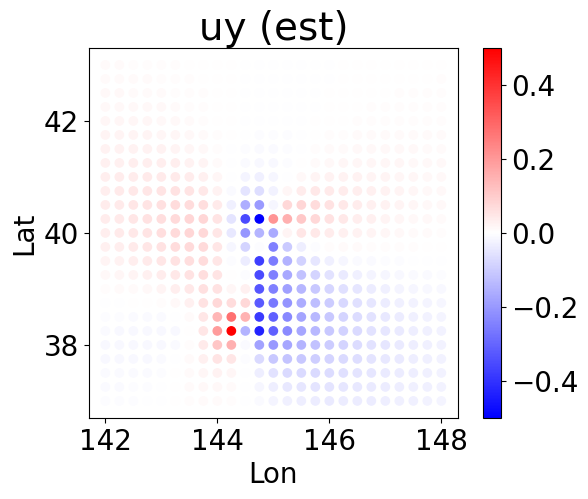

In [21]:
fig, ax = plt.subplots()
im = ax.scatter(Lon, Lat, c=uy, cmap="bwr", vmin=-0.5, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.set_title("uy (est)", fontsize=28)
fig.colorbar(im)
fig.show()
# plt.tight_layout()
# fig.savefig("figs_loss/uy_est.png")

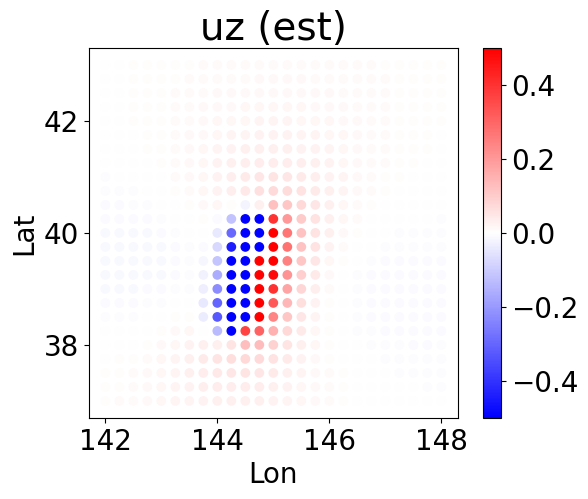

In [22]:
fig, ax = plt.subplots()
im = ax.scatter(Lon, Lat, c=uz, cmap="bwr", vmin=-0.5, vmax=0.5)
ax.set_aspect("equal")
ax.set_xlabel("Lon")
ax.set_ylabel("Lat")
ax.set_title("uz (est)", fontsize=28)
fig.colorbar(im)
fig.show()
# plt.tight_layout()
# fig.savefig("figs_loss/uz_est.png")